In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [159]:
# Cell for configs

RANDOM_SEED = 99

In [160]:

def get_both_components(intersection):
    '''
        Get both x and y components/coordinates for intersecting landmark points
    '''
    new_array = []
    for element in intersection:
        new_array.append(element)  # Add the element itself
        if element % 2 == 0:  # Check if even
            new_array.append(element +1)
        else:  # If odd
            new_array.append(element -1)
    
    final_array = np.array(sorted(list(set(new_array))))
    return final_array

def plot_vectors(vectors,dataset_name):
    # Prepare the origin points (set to (0, 0) for all vectors)
    origin_x = np.zeros(vectors.shape[0])
    origin_y = np.zeros(vectors.shape[0])
    
    # Separate the x and y components of the vectors
    vector_x = vectors[:, 0]
    vector_y = vectors[:, 1]
    
    # Plot the vectors
    plt.figure(figsize=(8, 8))
    plt.quiver(origin_x, origin_y, vector_x, vector_y, angles='xy', scale_units='xy', scale=1, color='r')
    plt.xlim(-20000, 20000)
    plt.ylim(-20000, 20000)
    plt.grid()
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(dataset_name)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def get_angles(vectors):
    '''
        Returns angles made by vectors in degrees
    '''
    angles_radians = np.arctan2(vectors[:, 1], vectors[:, 0])

    # Convert angles to degrees
    angles_degrees = np.degrees(angles_radians)
    
    # Normalize negative angles to be in the range [0, 360]
    angles_degrees = np.where(angles_degrees < 0, angles_degrees + 360, angles_degrees)

    return angles_degrees

def get_resultant_vector(df: pd.DataFrame):
    '''
        Returns resultant vector list (2d array) and magnitude list (magnitude of resultant vector)
    '''
    vectors = []
    list_magnitude = []
    # Compute resultant vectors
    for i in range(df.shape[0]):
        row = list(df.iloc[i])
        resultant_vector = np.array([sum(row[0::2]), sum(row[1::2])])
        list_magnitude.append(np.linalg.norm(resultant_vector))
        vectors.append(resultant_vector)

    return np.array(vectors),list_magnitude

# Angry


In [161]:
#ANG
iim_ang = np.array([21, 37, 65, 87, 117, 167, 213, 219, 265, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 425, 429, 431, 525, 547, 577, 627, 671, 677, 723, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 865, 869, 871])
jaffe_ang = np.array([33, 35, 37, 65, 87, 117, 167, 169, 171, 183, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 525, 547, 627, 629, 631, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 811, 813, 837, 843, 845, 849, 857, 861, 863])
intersection = np.intersect1d(iim_ang, jaffe_ang)

In [162]:
intersection = get_both_components(intersection)

(500, 110)


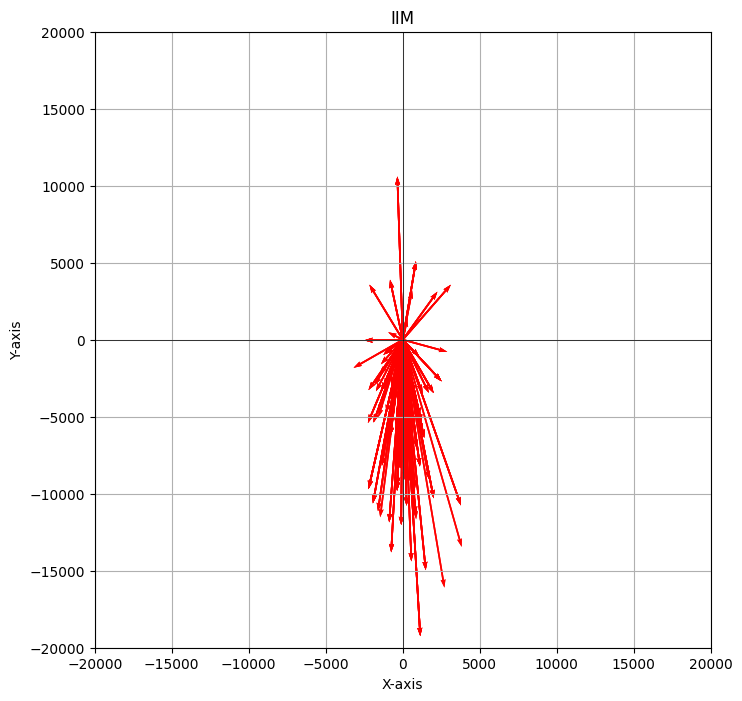

In [163]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/iim/ANG.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

iim_vectors,iim_magnitude =get_resultant_vector(df)

iim_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'IIM')

(500, 110)


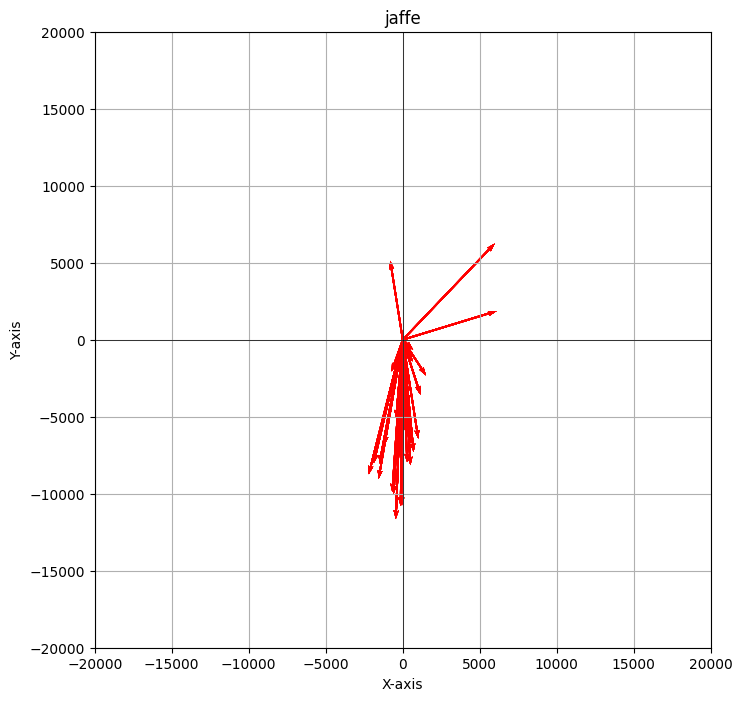

In [164]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/ANG.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

Skewness of IIM(ANG): 0.912
Skewness of RADBOUD(ANG): -0.108


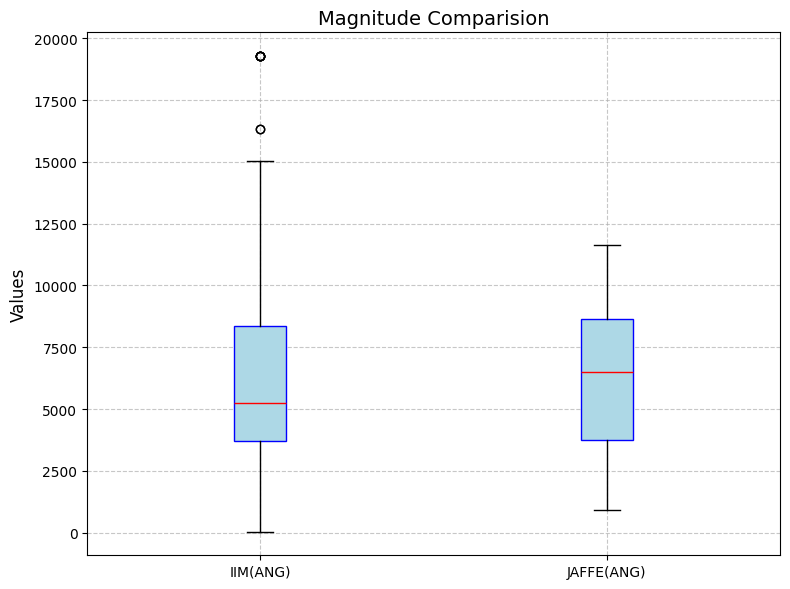

In [165]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(ANG)', 'JAFFE(ANG)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): -2.286
Skewness of RADBOUD(ANG): -2.479


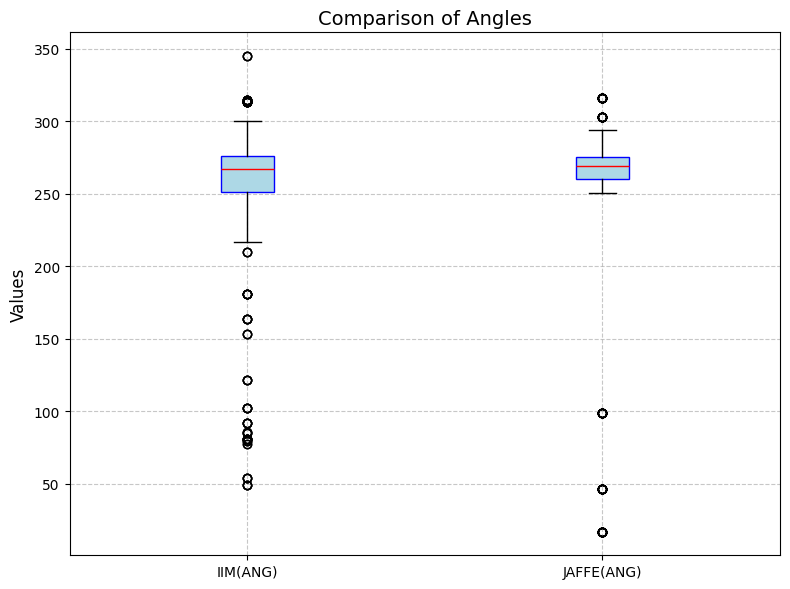

In [166]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['IIM(ANG)', 'JAFFE(ANG)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [167]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 115786.0, p-value: 0.043616743232061515
There is a significant difference between the angles.


In [168]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 115424.0, p-value: 0.035990623758542714
There is a significant difference between the magnitudes.


In [169]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic             1.511493
p-value                        0.23
number of permutations          999
Name: PERMANOVA results, dtype: object


# Happy

In [121]:
# #HPY
iim_hpy = np.array([21, 37, 65, 117, 167, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 547, 577, 627, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 869, 871])
jaffe_hpy = np.array([31, 33, 35, 37, 65, 87, 167, 169, 171, 183, 213, 271, 273, 281, 297, 299, 301, 305, 339, 341, 343, 351, 353, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 525, 627, 629, 631, 671, 729, 731, 739, 755, 757, 759, 789, 791, 793, 801, 811, 813, 837, 843, 849, 857, 861, 863])
intersection = np.intersect1d(iim_hpy, jaffe_hpy)

In [122]:
intersection = get_both_components(intersection)

(500, 92)


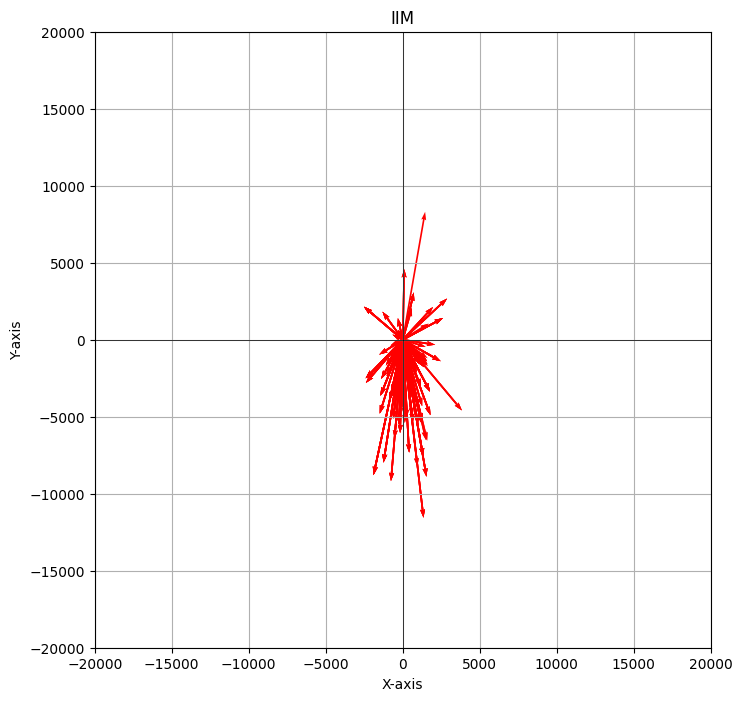

In [123]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/iim/HPY.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

iim_vectors,iim_magnitude =get_resultant_vector(df)

iim_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'IIM')

(500, 92)


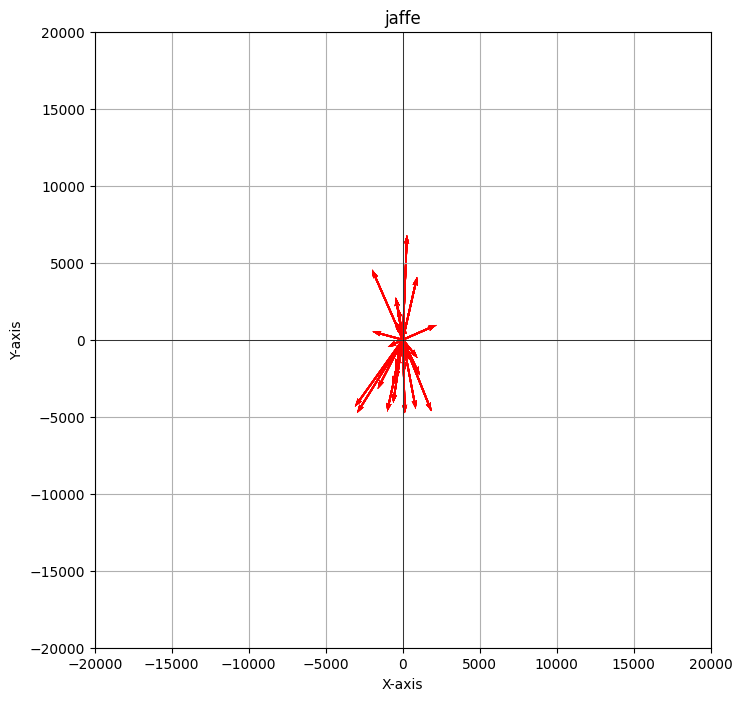

In [124]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/HPY.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

Skewness of IIM(ANG): 1.152
Skewness of RADBOUD(ANG): 0.558


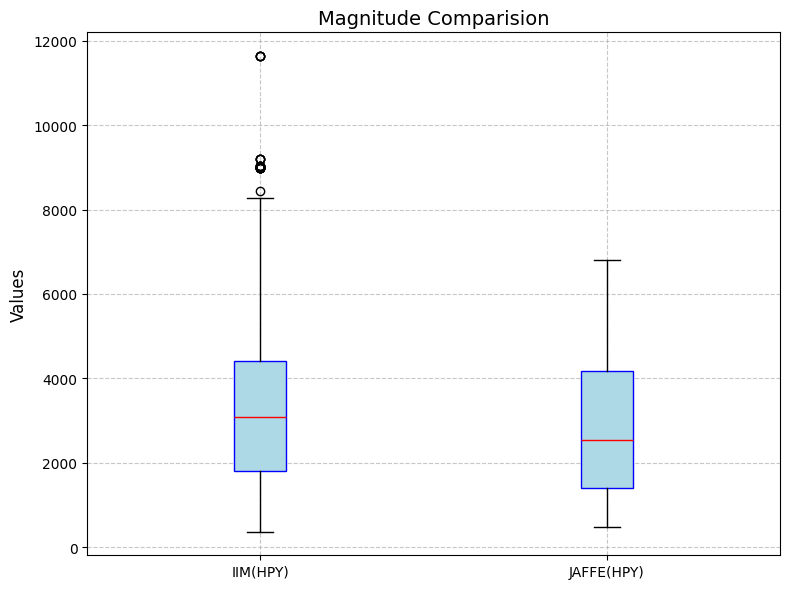

In [125]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(HPY)', 'JAFFE(HPY)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): -1.934
Skewness of RADBOUD(ANG): -0.692


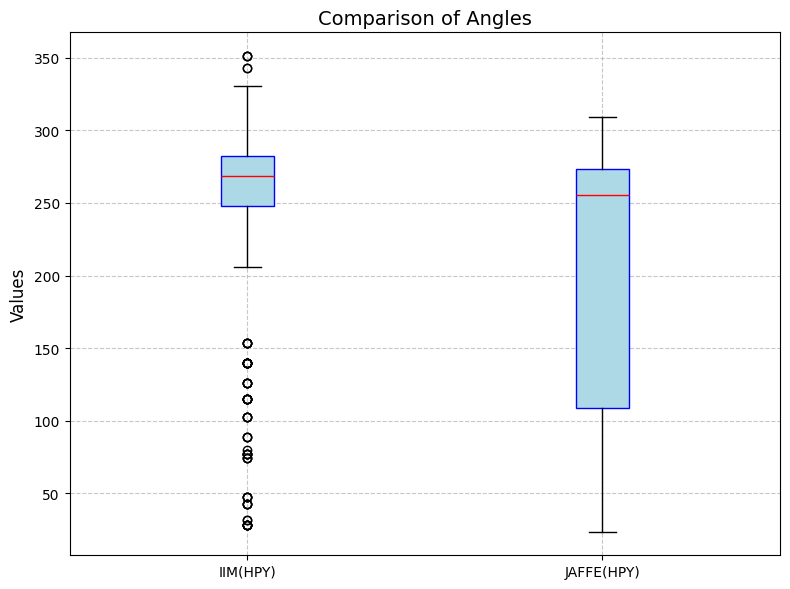

In [126]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['IIM(HPY)', 'JAFFE(HPY)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [127]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 162160.0, p-value: 4.0210626923013543e-16
There is a significant difference between the angles.


In [128]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 140485.0, p-value: 0.0006961176900630708
There is a significant difference between the magnitudes.


In [129]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic            83.675027
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


# SAD

In [130]:
#SAD
iim_sad = np.array([21, 37, 65, 87, 117, 167, 213, 219, 265, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 547, 577, 627, 671, 677, 723, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 869, 871])
jaffe_sad = np.array([31, 33, 35, 37, 65, 87, 167, 169, 171, 181, 183, 213, 271, 273, 277, 281, 293, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 525, 547, 627, 629, 631, 643, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 809, 811, 813, 837, 843, 845, 849, 857, 861, 863])
intersection = np.intersect1d(iim_ang, jaffe_sad)

In [131]:
intersection = get_both_components(intersection)

(500, 106)


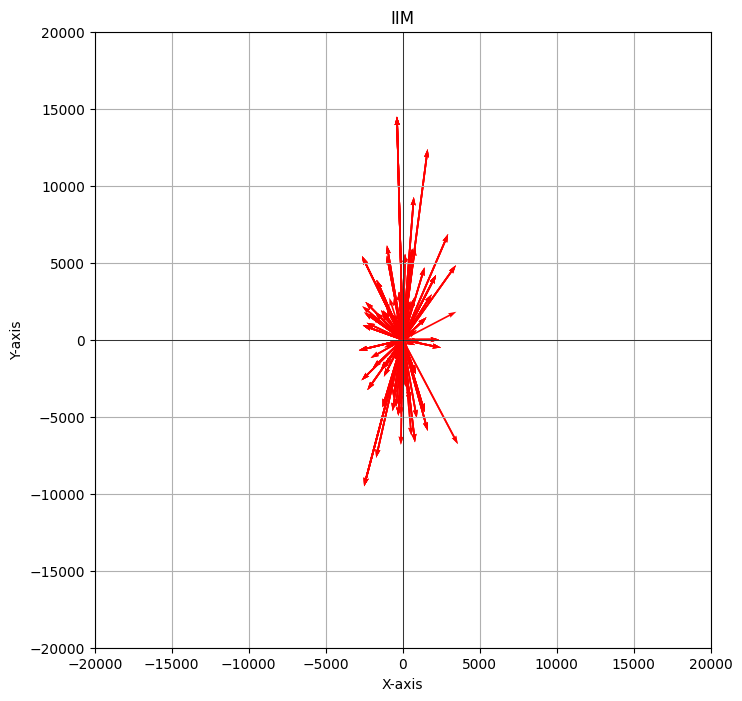

In [132]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/iim/SAD.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

iim_vectors,iim_magnitude =get_resultant_vector(df)

iim_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'IIM')

(500, 106)


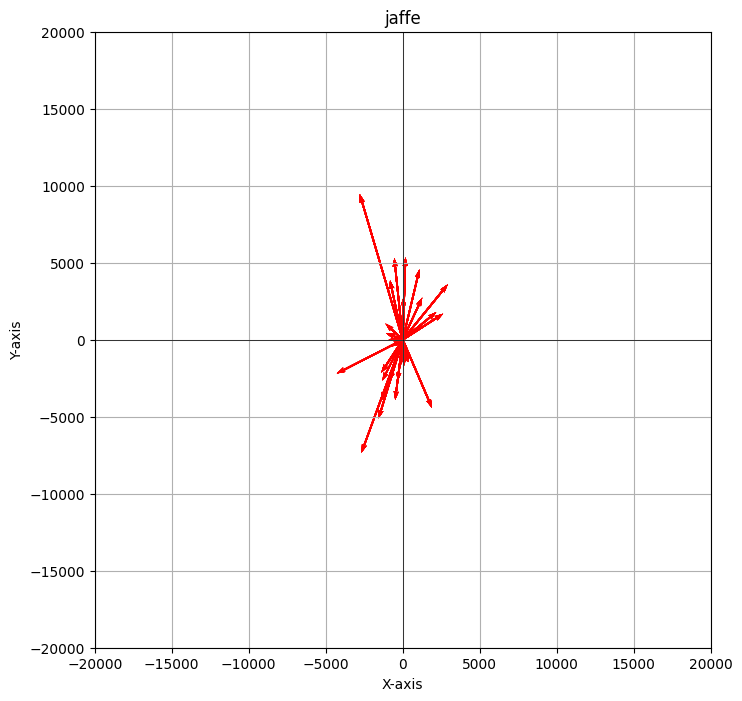

In [133]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/SAD.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

Skewness of IIM(ANG): 2.020
Skewness of RADBOUD(ANG): 1.022


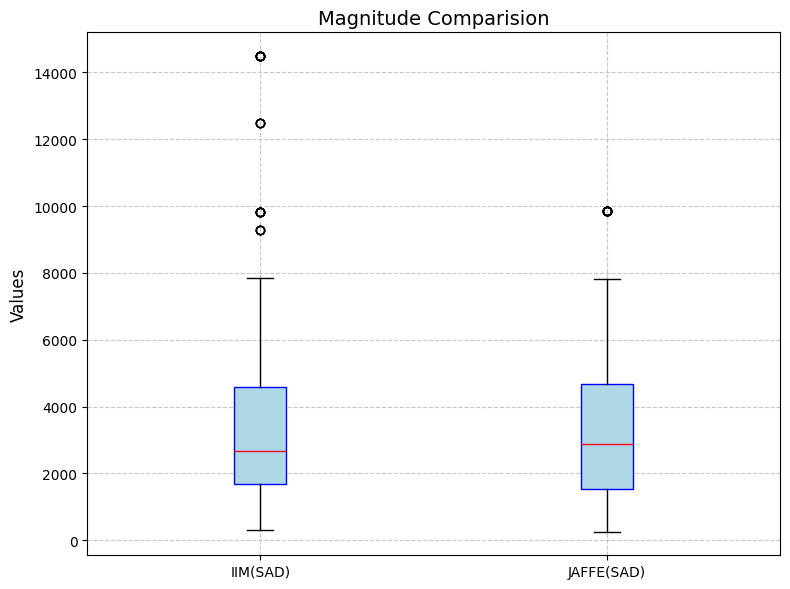

In [134]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(SAD)', 'JAFFE(SAD)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): 0.110
Skewness of RADBOUD(ANG): -0.391


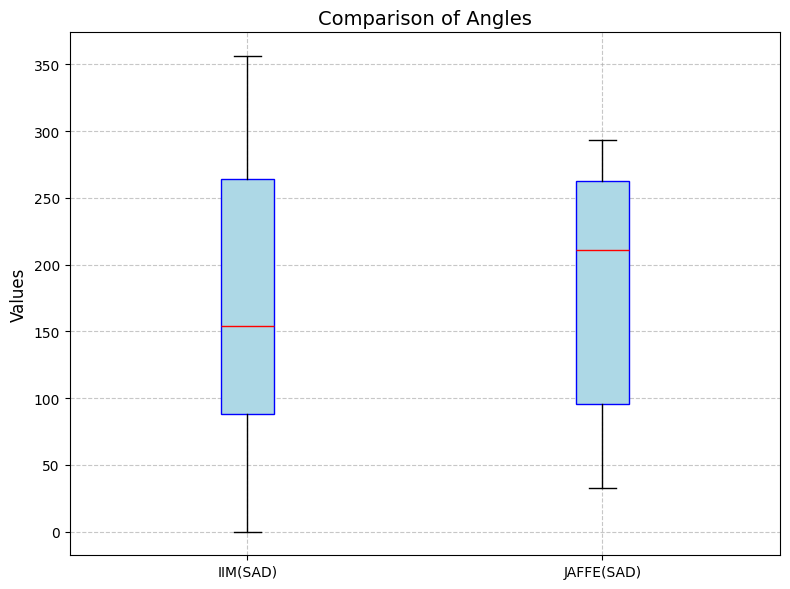

In [135]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['IIM(SAD)', 'JAFFE(SAD)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [136]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 120111.0, p-value: 0.28435791095291574
There is no significant difference between the angles.


In [137]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 122180.0, p-value: 0.5369246578518214
There is no significant difference between the magnitudes


In [138]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic             1.633778
p-value                       0.205
number of permutations          999
Name: PERMANOVA results, dtype: object


# SUR

In [139]:
# SUR
iim_sur = np.array([29, 31, 33, 35, 37, 65, 87, 117, 167, 169, 171, 173, 175, 179, 181, 183, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 357, 359, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 431, 525, 547, 577, 627, 629, 631, 633, 635, 639, 641, 643, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 805, 807, 809, 811, 813, 837, 843, 845, 849, 857, 861, 863, 871])
jaffe_sur = np.array([29, 31, 33, 35, 37, 65, 155, 167, 169, 171, 173, 175, 177, 179, 181, 183, 191, 193, 213, 281, 293, 297, 299, 301, 305, 339, 341, 343, 351, 353, 357, 359, 361, 363, 365, 389, 399, 401, 403, 409, 417, 423, 525, 615, 627, 629, 631, 633, 635, 637, 639, 641, 643, 649, 651, 671, 739, 751, 755, 757, 759, 789, 791, 793, 801, 805, 807, 809, 811, 813, 837, 843, 849, 857, 863])
intersection = np.intersect1d(iim_sur, jaffe_sur)

In [140]:
intersection = get_both_components(intersection)

(500, 130)


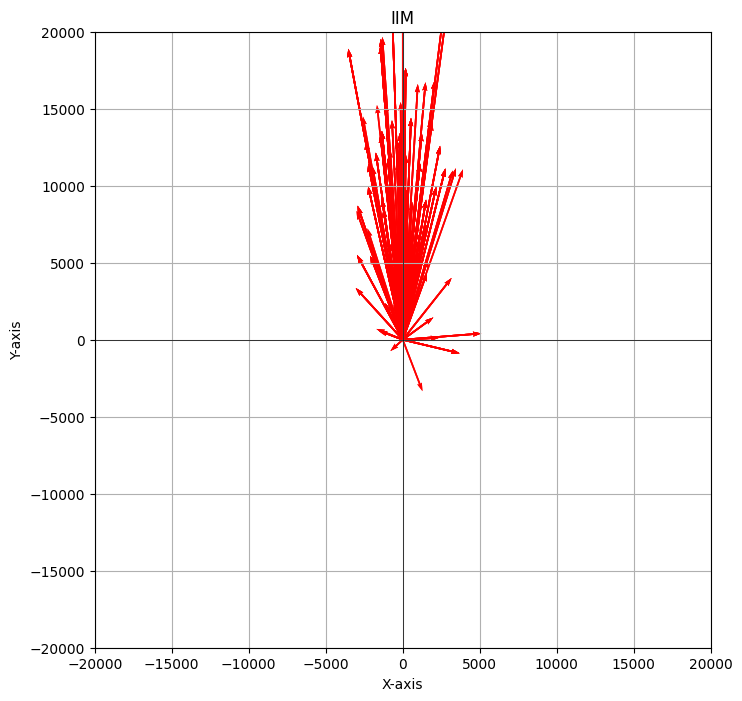

In [142]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/iim/SUR.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

iim_vectors,iim_magnitude =get_resultant_vector(df)

iim_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'IIM')

(500, 130)


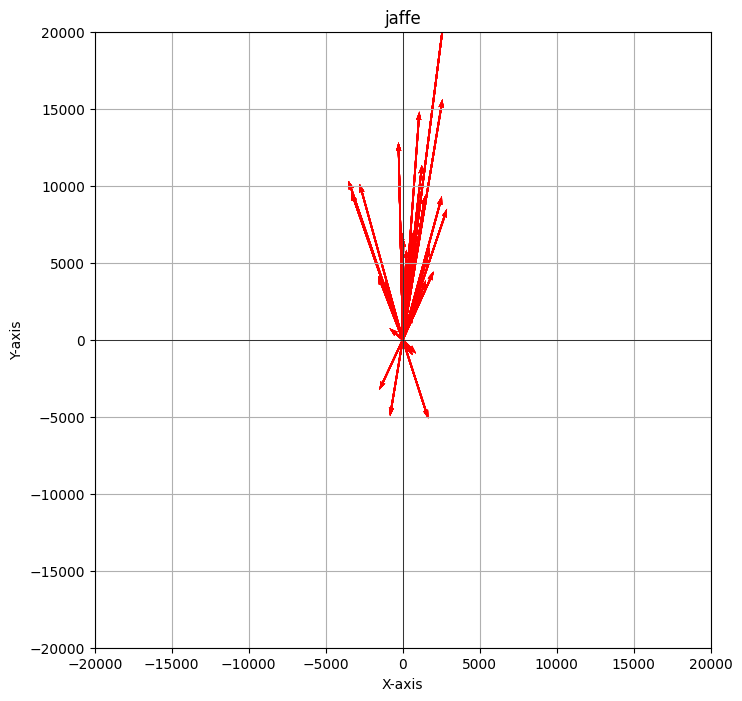

In [143]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/SUR.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

Skewness of IIM(ANG): 0.558
Skewness of RADBOUD(ANG): 1.207


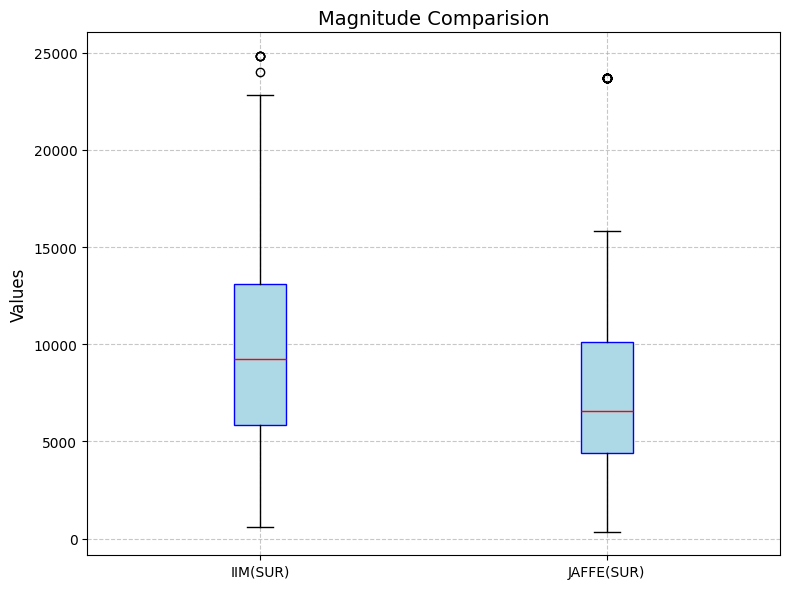

In [144]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(SUR)', 'JAFFE(SUR)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): 4.081
Skewness of RADBOUD(ANG): 1.627


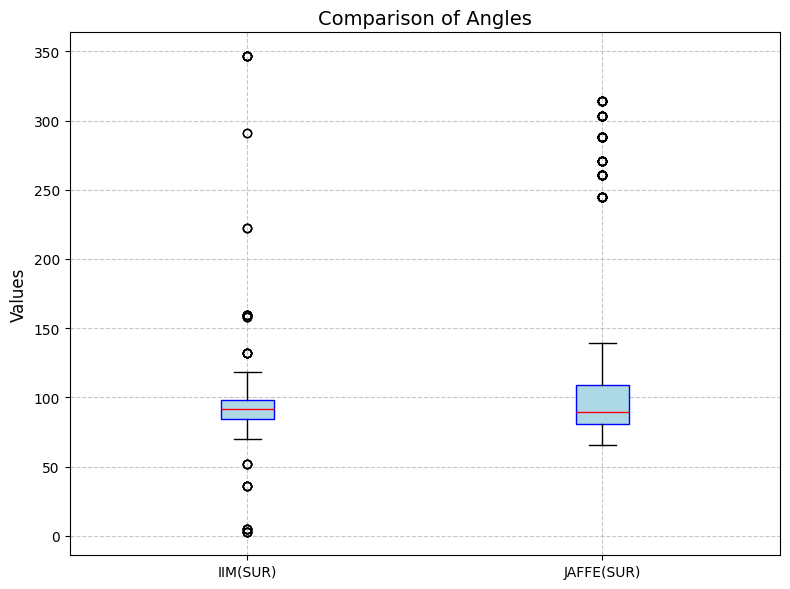

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['IIM(SUR)', 'JAFFE(SUR)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [146]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 128355.0, p-value: 0.46256175845440395
There is no significant difference between the angles.


In [147]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 158813.0, p-value: 1.312162880770562e-13
There is a significant difference between the magnitudes.


In [148]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic            63.546187
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


# FER

In [149]:
# SUR
iim_sur = np.array([37, 65, 87, 117, 167, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 547, 577, 627, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 837, 843, 845, 849, 857, 861, 863, 869, 871])
jaffe_sur = np.array([29, 31, 33, 35, 37, 65, 155, 167, 169, 171, 173, 175, 177, 179, 181, 183, 213, 271, 273, 281, 293, 297, 299, 301, 305, 339, 341, 343, 351, 353, 357, 359, 361, 363, 365, 389, 399, 401, 403, 409, 417, 421, 423, 525, 627, 629, 631, 633, 635, 637, 639, 641, 643, 671, 729, 731, 739, 755, 757, 759, 789, 791, 793, 801, 805, 807, 809, 811, 813, 837, 843, 849, 857, 861, 863])
intersection = np.intersect1d(iim_sur, jaffe_sur)

In [150]:
intersection = get_both_components(intersection)

(500, 90)


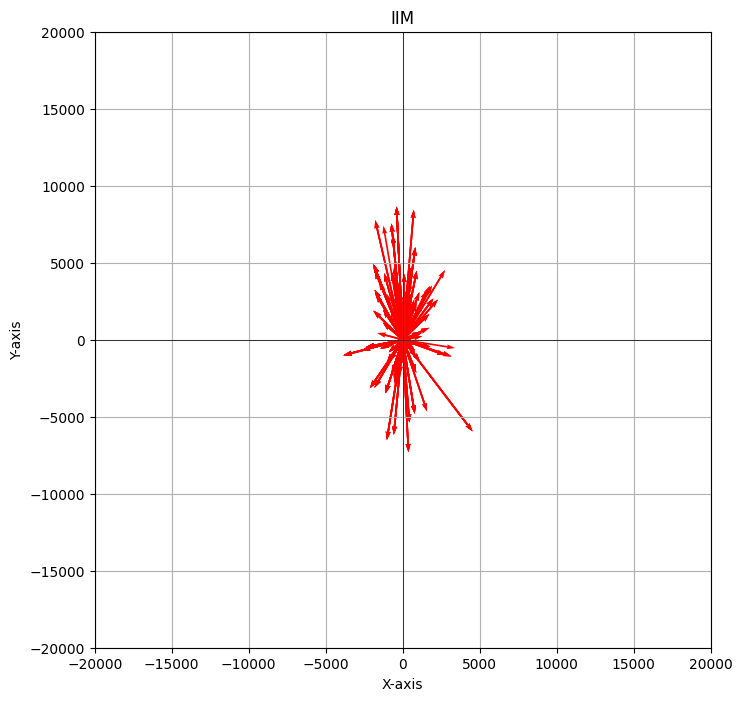

In [151]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/iim/FER.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

iim_vectors,iim_magnitude =get_resultant_vector(df)

iim_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'IIM')

(500, 90)


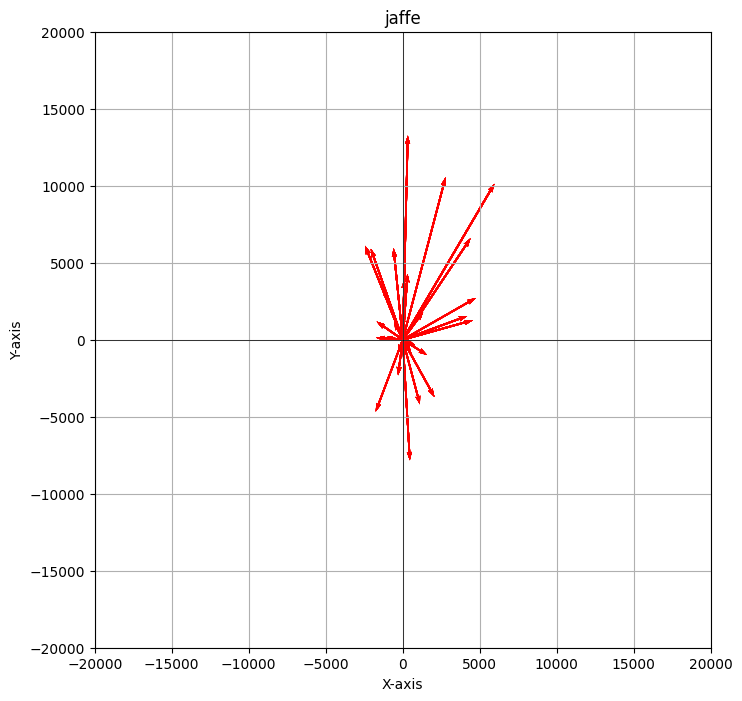

In [152]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/FER.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

Skewness of IIM(FER): 1.062
Skewness of RADBOUD(FER): 1.065


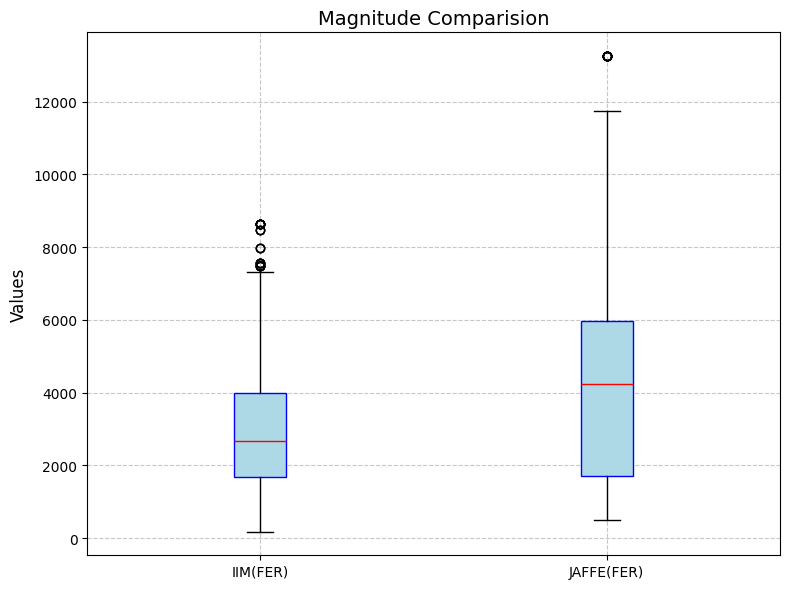

In [153]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(FER): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(FER): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(FER)', 'JAFFE(FER)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(FER): 0.357
Skewness of RADBOUD(FER): 0.427


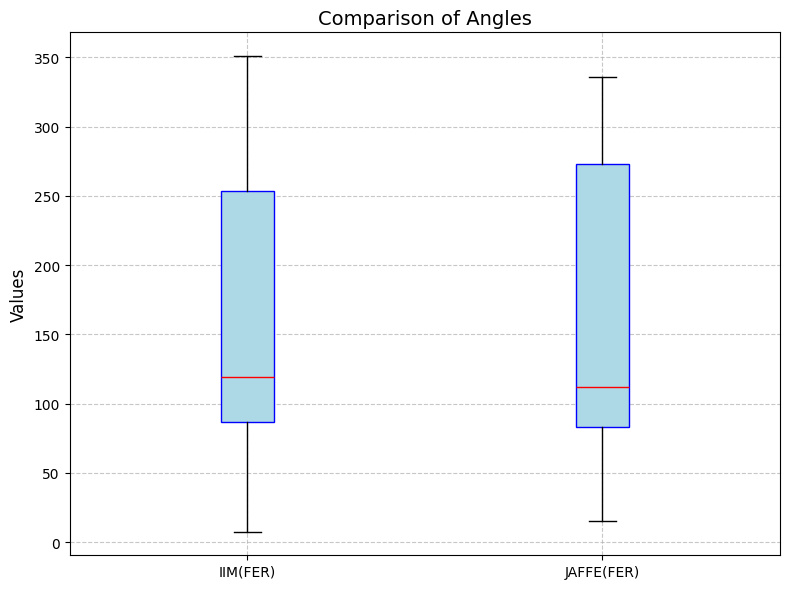

In [154]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(FER): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(FER): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['IIM(FER)', 'JAFFE(FER)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [155]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 128831.0, p-value: 0.4015371921881711
There is no significant difference between the angles.


In [156]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 105803.0, p-value: 2.6220279178340943e-05
There is a significant difference between the magnitudes.


In [157]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic            29.249147
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


# <-----------END----------->

In [163]:

# # SUR
# iim_ang = np.array([30, 32, 34, 36, 38, 66, 88, 118, 168, 170, 172, 174, 176, 180, 182, 184, 214, 272, 274, 278, 282, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 358, 360, 362, 364, 366, 390, 400, 402, 404, 406, 410, 418, 422, 424, 432, 526, 548, 578, 628, 630, 632, 634, 636, 640, 642, 644, 672, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 806, 808, 810, 812, 814, 838, 844, 846, 850, 858, 862, 864, 872])
# radboud_ang = np.array([30, 32, 34, 36, 38, 66, 156, 168, 170, 172, 174, 176, 178, 180, 182, 184, 192, 194, 214, 282, 294, 298, 300, 302, 306, 340, 342, 344, 352, 354, 358, 360, 362, 364, 366, 390, 400, 402, 404, 410, 418, 424, 526, 616, 628, 630, 632, 634, 636, 638, 640, 642, 644, 650, 652, 672, 740, 752, 756, 758, 760, 790, 792, 794, 802, 806, 808, 810, 812, 814, 838, 844, 850, 858, 864])
# intersection = np.intersect1d(iim_ang, radboud_ang)

# print("Intersection:", intersection)

# #HPY
# iim_ang = np.array([22, 38, 66, 118, 168, 214, 272, 274, 278, 282, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 366, 386, 390, 400, 402, 404, 406, 410, 418, 422, 424, 430, 432, 526, 548, 578, 628, 672, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 814, 834, 838, 844, 846, 850, 858, 862, 864, 870, 872])
# radboud_ang = np.array([32, 34, 36, 38, 66, 88, 168, 170, 172, 184, 214, 272, 274, 282, 298, 300, 302, 306, 340, 342, 344, 352, 354, 362, 364, 366, 390, 400, 402, 404, 406, 410, 418, 422, 424, 526, 628, 630, 632, 672, 730, 732, 740, 756, 758, 760, 790, 792, 794, 802, 812, 814, 838, 844, 850, 858, 862, 864])
# intersection = np.intersect1d(iim_ang, radboud_ang)

# print("Intersection:", intersection)

#ANG
iim_ang = np.array([22, 38, 66, 88, 118, 168, 214, 220, 266, 272, 274, 278, 282, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 366, 386, 390, 400, 402, 404, 406, 410, 418, 422, 424, 426, 430, 432, 526, 548, 578, 628, 672, 678, 724, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 814, 834, 838, 844, 846, 850, 858, 862, 864, 866, 870, 872])
radboud_ang = np.array([34, 36, 38, 66, 88, 118, 168, 170, 172, 184, 214, 272, 274, 278, 282, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 364, 366, 390, 400, 402, 404, 406, 410, 418, 422, 424, 430, 526, 548, 628, 630, 632, 672, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 812, 814, 838, 844, 846, 850, 858, 862, 864])
intersection = np.intersect1d(iim_ang, radboud_ang)

# print("Intersection:", intersection)

# #SAD
# iim_ang = np.array([22, 38, 66, 88, 118, 168, 214, 220, 266, 272, 274, 278, 282, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 366, 386, 390, 400, 402, 404, 406, 410, 418, 422, 424, 430, 432, 526, 548, 578, 628, 672, 678, 724, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 814, 834, 838, 844, 846, 850, 858, 862, 864, 870, 872])
# radboud_ang = np.array([32, 34, 36, 38, 66, 88, 168, 170, 172, 182, 184, 214, 272, 274, 278, 282, 294, 298, 300, 302, 306, 340, 342, 344, 346, 352, 354, 362, 364, 366, 390, 400, 402, 404, 406, 410, 418, 422, 424, 526, 548, 628, 630, 632, 644, 672, 730, 732, 736, 740, 756, 758, 760, 790, 792, 794, 796, 802, 810, 812, 814, 838, 844, 846, 850, 858, 862, 864])
# intersection = np.intersect1d(iim_ang, radboud_ang)

# print("Intersection:", intersection)

In [164]:


new_array = []
for element in intersection:
    new_array.append(element)  # Add the element itself
    if element % 2 == 0:  # Check if even
        new_array.append(element - 1)
    else:  # If odd
        new_array.append(element + 1)

intersection = np.array(sorted(list(set(new_array))))

In [165]:
intersection

array([ 37,  38,  65,  66,  87,  88, 117, 118, 167, 168, 213, 214, 271,
       272, 273, 274, 277, 278, 281, 282, 297, 298, 299, 300, 301, 302,
       305, 306, 339, 340, 341, 342, 343, 344, 345, 346, 351, 352, 353,
       354, 365, 366, 389, 390, 399, 400, 401, 402, 403, 404, 405, 406,
       409, 410, 417, 418, 421, 422, 423, 424, 429, 430, 525, 526, 547,
       548, 627, 628, 671, 672, 729, 730, 731, 732, 735, 736, 739, 740,
       755, 756, 757, 758, 759, 760, 789, 790, 791, 792, 793, 794, 795,
       796, 801, 802, 813, 814, 837, 838, 843, 844, 845, 846, 849, 850,
       857, 858, 861, 862, 863, 864])

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 2
# Read the CSV file
df = pd.read_csv('landmark_differences_csvs/iim/ANG.csv')
print(df.shape)
df = df[[str(x) for x in intersection]]
df = df.sample(30,random_state=RANDOM_SEED)
# df = df[[str(x) for x in intersection]]


temp_lst = []
iim_magnitude = []
magnitude = 0
iim_final = []
# Compute resultant vectors
for i in range(df.shape[0]):
    row = list(df.iloc[i])
    resultant_vector = np.array([sum(row[0::2]), sum(row[1::2])])
    iim_magnitude.append(np.linalg.norm(resultant_vector))
    magnitude += np.linalg.norm(resultant_vector)
    # resultant_vector /= np.linalg.norm(resultant_vector)
    temp_lst.append(resultant_vector)

magnitude /= 30

print("Magnitude:",magnitude)


# mean = np.mean(iim_magnitude, axis=0)
# std = np.std(iim_magnitude, axis=0)

# iim_magnitude = (iim_magnitude - mean) / std
# Convert the list to a numpy array
vectors = np.array(temp_lst)

print(vectors)

# Calculate angles in radians
angles_radians = np.arctan2(vectors[:, 1], vectors[:, 0])

# Convert angles to degrees
angles_degrees = np.degrees(angles_radians)

# Normalize negative angles to be in the range [0, 360]
angles_degrees = np.where(angles_degrees < 0, angles_degrees + 360, angles_degrees)

# Print the angles
print(angles_degrees)

# mean = np.mean(angles_degrees, axis=0)
# std = np.std(angles_degrees, axis=0)

# angles_degrees = (angles_degrees - mean) / std

# Prepare the origin points (set to (0, 0) for all vectors)
origin_x = np.zeros(vectors.shape[0])
origin_y = np.zeros(vectors.shape[0])

# Separate the x and y components of the vectors
vector_x = vectors[:, 0]
vector_y = vectors[:, 1]

# Plot the vectors
plt.figure(figsize=(8, 8))
plt.quiver(origin_x, origin_y, vector_x, vector_y, angles='xy', scale_units='xy', scale=1, color='r')
plt.xlim(-40000, 40000)
plt.ylim(-40000, 40000)
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('IIM')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

print(np.mean(vectors,axis=0))

iim_final = angles_degrees + iim_magnitude

(100, 936)


KeyError: "None of [Index([ 37,  38,  65,  66,  87,  88, 117, 118, 167, 168,\n       ...\n       845, 846, 849, 850, 857, 858, 861, 862, 863, 864],\n      dtype='int64', length=110)] are in the [columns]"

In [44]:
iim_final

array([13736.50557301, 28614.34404872,  8619.76280299,  9445.08306039,
       14715.27453501, 11713.39773371,  5695.53816575, 23556.26180674,
       26867.03486696,  1907.70806082, 23388.29250463,  9213.21268475,
       11054.84944517,  7464.38714731, 17076.5536714 , 19472.67478883,
       16071.30035102,  7681.17101423, 17896.36982688, 36891.85532413,
       18502.79643579,  5873.05544352,  9830.15078303, 28336.77811047,
        6275.01992223,  7804.6007657 ,  7819.11228309, 10017.20676632,
       19644.79543409, 16277.01296541])

In [45]:
print(len(iim_magnitude))
len(angles_degrees)

30


30

In [46]:
iim_vector = vectors
iim_angles = angles_degrees

(30, 936)
(30, 936)
Magnitude: 6351.988364824809
[[  1141.27911825  -3555.57936751]
 [ -1512.59322183  -8038.62125616]
 [  -684.35613306  -9882.73380192]
 [   703.1645024   -7287.80269914]
 [  -434.58036889  -5103.5241856 ]
 [  -591.78508223 -10014.39641362]
 [  6087.18794806   1861.48708527]
 [ -1882.36256344  -8003.38099501]
 [   151.96566024  -5866.37947205]
 [    69.14393243  -2158.44048242]
 [ -2207.52608629  -8729.51746596]
 [  -451.1449499  -11628.48998928]
 [   353.92003561  -4151.2091217 ]
 [   670.81874214   -651.07141128]
 [  5967.56984135   6241.4690683 ]
 [   628.98242389  -1406.82056859]
 [   279.74103931  -7942.57064516]
 [  -140.90178361 -10786.16910338]
 [   -54.8452636  -10774.03990448]
 [ -1567.55693913  -9027.40295126]
 [   523.16100457  -6732.77504287]
 [   197.91939047  -2841.82792355]
 [ -1190.38036529  -6824.81008049]
 [  1506.81169199  -2316.66393417]
 [  1004.5441484   -6413.79598882]
 [   277.30828709  -6257.2176637 ]
 [  -812.952804     5120.57725933]
 [   5

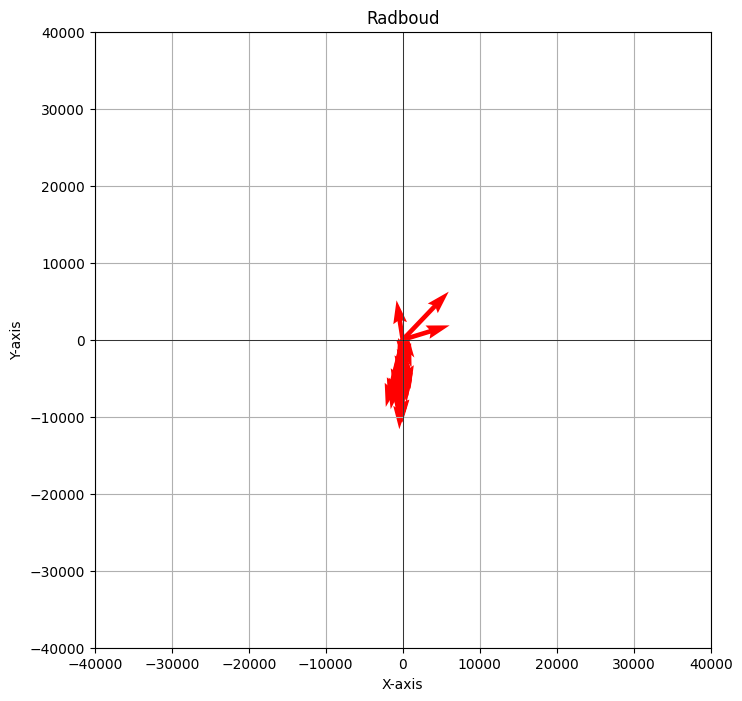

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


RANDOM_SEED = 2
# Read the CSV file
df = pd.read_csv('landmark_differences_csvs/jaffe/ANG.csv')
print(df.shape)

df = df.sample(30,random_state=RANDOM_SEED)
print(df.shape)
df = df[[str(x) for x in intersection]]

temp_lst = []
radboud_magnitude = []
magnitude = 0
radboud_final = []

# Compute resultant vectors
for i in range(df.shape[0]):
    row = list(df.iloc[i])
    resultant_vector = np.array([sum(row[0::2]), sum(row[1::2])])
    radboud_magnitude.append(np.linalg.norm(resultant_vector))
    magnitude += np.linalg.norm(resultant_vector)
    # resultant_vector /= np.linalg.norm(resultant_vector)
    temp_lst.append(resultant_vector)

magnitude /= 30

print("Magnitude:",magnitude)
# Convert the list to a numpy array


# mean = np.mean(radboud_magnitude, axis=0)
# std = np.std(radboud_magnitude, axis=0)

# radboud_magnitude = (radboud_magnitude-mean)/std

vectors = np.array(temp_lst)

print(vectors)
# Calculate angles in radians
angles_radians = np.arctan2(vectors[:, 1], vectors[:, 0])

# Convert angles to degrees
angles_degrees = np.degrees(angles_radians)

# Normalize negative angles to be in the range [0, 360]
angles_degrees = np.where(angles_degrees < 0, angles_degrees + 360, angles_degrees)

# mean = np.mean(angles_degrees, axis=0)
# std = np.std(angles_degrees, axis=0)

# angles_degrees = (angles_degrees-mean)/std
# Print the angles
print(angles_degrees)


# Prepare the origin points (set to (0, 0) for all vectors)
origin_x = np.zeros(vectors.shape[0])
origin_y = np.zeros(vectors.shape[0])

# Separate the x and y components of the vectors
vector_x = vectors[:, 0]
vector_y = vectors[:, 1]

# Plot the vectors
plt.figure(figsize=(8, 8))
plt.quiver(origin_x, origin_y, vector_x, vector_y, angles='xy', scale_units='xy', scale=1, color='r')
plt.xlim(-40000, 40000)
plt.ylim(-40000, 40000)
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Radboud')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

radboud_final = angles_radians+radboud_magnitude

In [171]:
radboud_vector = vectors
radboud_angles = angles_degrees


In [172]:
iim_magnitude = np.array(iim_magnitude).flatten()
radboud_magnitude = np.array(radboud_magnitude).flatten()


Skewness of IIM(SUR): 0.816
Skewness of RADBOUD(SUR): -0.188


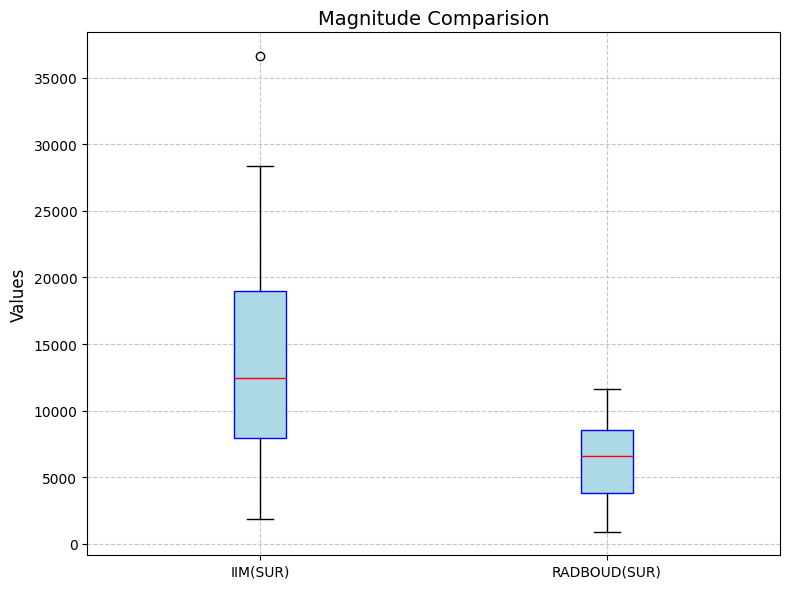

In [173]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
iim_skewness = skew(iim_magnitude)
radboud_skewness = skew(radboud_magnitude)

# Print skewness
print(f"Skewness of IIM(SUR): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(SUR): {radboud_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(iim_magnitude), np.array(radboud_magnitude)]
ax.boxplot(boxplot_data, labels=['IIM(SUR)', 'RADBOUD(SUR)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(SUR): -1.840
Skewness of RADBOUD(SUR): -2.585


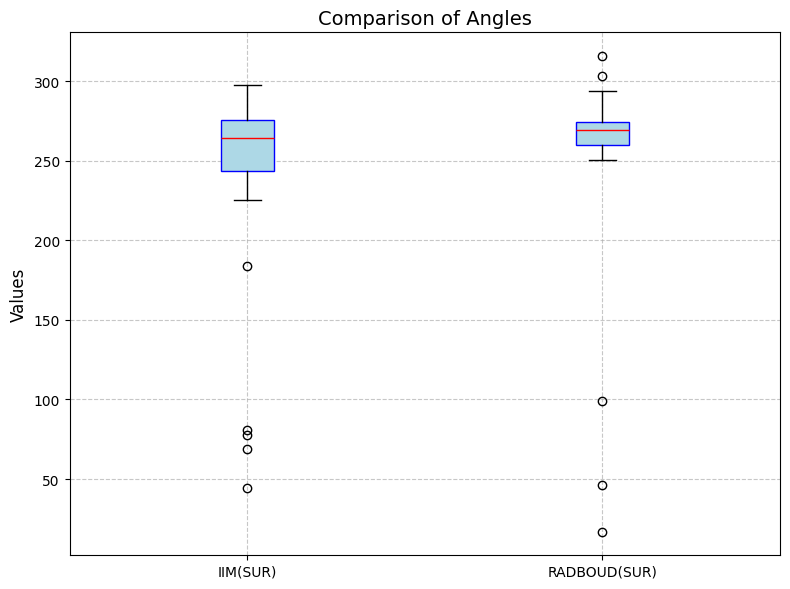

In [174]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
iim_skewness = skew(iim_angles)
radboud_skewness = skew(radboud_angles)

# Print skewness
print(f"Skewness of IIM(SUR): {iim_skewness:.3f}")
print(f"Skewness of RADBOUD(SUR): {radboud_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [iim_angles, radboud_angles]
ax.boxplot(boxplot_data, labels=['IIM(SUR)', 'RADBOUD(SUR)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [175]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_angles, radboud_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 393.0, p-value: 0.40353753915408586
There is no significant difference between the angles.


In [176]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_magnitude, radboud_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 735.0, p-value: 2.597359981294573e-05
There is a significant difference between the magnitudes.


In [177]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(iim_final, radboud_final, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 743.0, p-value: 1.5291673925716366e-05
There is a significant difference between the magnitudes.


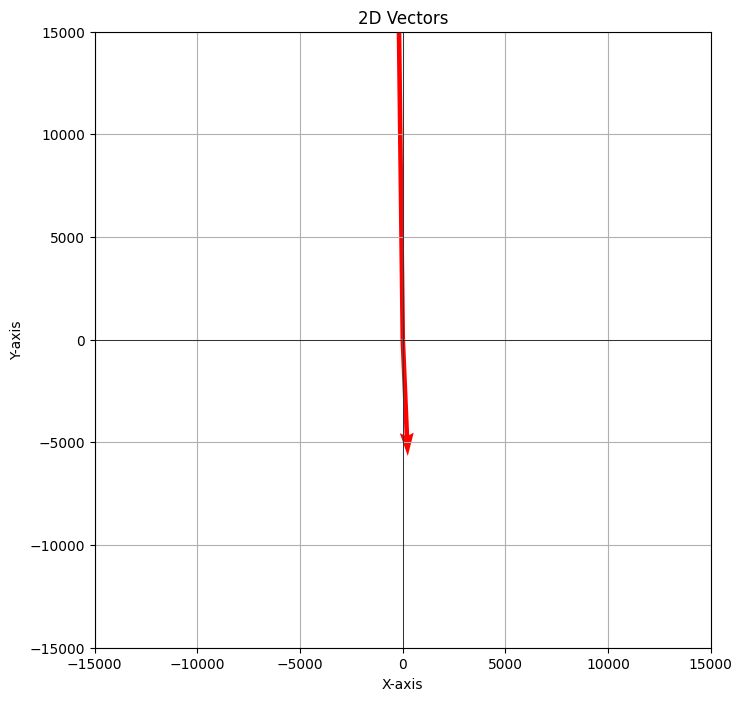

Cosine Similarity Matrix:
[[ 1.         -0.99952805]
 [-0.99952805  1.        ]]


In [178]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define the array
temp = np.array([[ -215.09597511, 17599.59830559],
                 [  243.38258192, -5663.81319228]])

vectors = temp
# Prepare the origin points (set to (0, 0) for all vectors)
origin_x = np.zeros(vectors.shape[0])
origin_y = np.zeros(vectors.shape[0])

# Separate the x and y components of the vectors
vector_x = vectors[:, 0]
vector_y = vectors[:, 1]

# Plot the vectors
plt.figure(figsize=(8, 8))
plt.quiver(origin_x, origin_y, vector_x, vector_y, angles='xy', scale_units='xy', scale=1, color='r')
plt.xlim(-15000, 15000)
plt.ylim(-15000, 15000)
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('2D Vectors')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Compute cosine similarity between each pair of vectors
cosine_sim_matrix = cosine_similarity(temp)

# Print the pairwise cosine similarity matrix
print("Cosine Similarity Matrix:")
print(cosine_sim_matrix)


In [179]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vector # 10 vectors in group 1
array2 = radboud_vector  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                      60
number of groups                  2
test statistic            10.200718
p-value                       0.002
number of permutations          999
Name: PERMANOVA results, dtype: object


In [ ]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = iim_vector # 10 vectors in group 1
array2 = radboud_vector  # 10 vectors in group 2

# Combine arrays and create labels
data = np.vstack([array1, array2])
labels = ['Group1'] * len(array1) + ['Group2'] * len(array2)

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=labels)
print(result)
